# **imports**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent)) # Damit Dataset richtig erkannt wird

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import math

## Self Attention

In [5]:
from torch import nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, in_channels, num_heads=12, attn_p=0, proj_p=0):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = in_channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.query = nn.Linear(in_channels, in_channels)        # Diese Daten werden nach und nach angepasst, starten random und werden dann durch das Training immer besser.
        self.value = nn.Linear(in_channels, in_channels)        # Es ist wichtig, dass die Dimensionen der Query, Key und Value gleich sind, damit wir die Attention berechnen können.
        self.key = nn.Linear(in_channels, in_channels)

        self.attn_p = attn_p
        self.proj_p = nn.Linear(in_channels, in_channels)
        self.proj_drop = nn.Dropout(proj_p)

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape

        q = self.query(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        x = F.scaled_dot_product_attention(q, k, v, dropout_p=self.attn_p)

        x = x.transpose(1,2).reshape(batch_size, seq_len, embed_dim)
        x = self.proj_drop(self.proj_p(x))
        return x


In [6]:
class MLP(nn.Module):

    def __init__(self, in_channels, mlp_ratio=4, mlp_p=0):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, in_channels * mlp_ratio)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(mlp_p)
        self.fc2 = nn.Linear(in_channels * mlp_ratio, in_channels)
        self.drop2 = nn.Dropout(mlp_p)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)

        x= self.fc2(x)
        x = self.drop2(x)
        return x



## Transformer Blocks


In [7]:

class ImageTransformerBlock(nn.Module):
    def __init__(self, in_channels, num_heads=4, mlp_ratio=2, proj_p=0, attn_p=0, mlp_p=0):
        super().__init__()

        self.norm1 = nn.LayerNorm(in_channels, eps=1e-6)
        self.attn = SelfAttention(in_channels=in_channels,
                                  num_heads=num_heads,
                                  attn_p=attn_p,
                                  proj_p=proj_p)

        self.norm2 = nn.LayerNorm(in_channels, eps=1e-6)
        self.mlp = MLP(in_channels=in_channels,
                       mlp_ratio=mlp_ratio,
                       mlp_p=mlp_p)

    def forward(self, x):
        batch_size, channels, height, width = x.shape

        ### 1. Übersetzer: Bild in flache Sequenz umwandeln -> (Batch, H*W, Channels)
        x = x.reshape(batch_size, channels, height*width).permute(0,2,1)

        ### 2. Attention anwenden
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        ### 3. Übersetzer: Sequenz wieder zu einem Bild zusammenfalten -> (Batch, Channels, H, W)
        x = x.permute(0,2,1).reshape(batch_size, channels, height, width)
        return x

In [8]:
from torch import nn


class PointTransformerBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 num_heads=4,
                 mlp_ratio=2,
                 proj_p=0,
                 attn_p=0,
                 mlp_p=0):

        super().__init__()

        # 1. Self-Attention (Punkte reden mit Punkten, um die Form zu glätten)
        self.norm1 = nn.LayerNorm(in_channels, eps=1e-6)
        self.attn = SelfAttention(in_channels=in_channels,
                                  num_heads=num_heads,
                                  attn_p=attn_p,
                                  proj_p=proj_p)


        # 2. MLP (Punkte verarbeiten ihre Position und die Bild-Features isoliert)
        self.norm2 = nn.LayerNorm(in_channels, eps=1e-6)
        self.mlp = MLP(in_channels=in_channels,
                       mlp_ratio=mlp_ratio,
                       mlp_p=mlp_p)

    def forward(self, x):
        # x hat hier schon die Form (Batch, n_punkte, in_channels)
        # Und ganz wichtig: 'x' enthält hier bereits die eingesaugten Bild-Features!

        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x

## UNET

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, groupnorm_num_groups=16):
        super().__init__()

        self.groupnorm1 = nn.GroupNorm(groupnorm_num_groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same")

        self.groupnorm2 = nn.GroupNorm(groupnorm_num_groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same")

        self.resize_channels = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual_connection = x

        x = self.groupnorm1(x)
        x = F.silu(x)
        x = self.conv1(x)


        x = self.groupnorm2(x)
        x = F.silu(x)
        x = self.conv2(x)

        x = x + self.resize_channels(residual_connection)
        return x

class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding="same")
        )

    def forward(self, x):
        return self.upsample(x)



class FeatureUNET(nn.Module):
    def __init__(self, in_channels=3, out_features=64, start_dim=64, dim_mults=(1,2,4), residual_blocks_per_group=1, groupnorm_num_groups=16):
        super().__init__()

        self.input_image_channels = in_channels
        channel_sizes = [start_dim * i for i in dim_mults]
        starting_channel_size, ending_channel_size = channel_sizes[0], channel_sizes[-1]

        self.encoder_config = []

        for idx, d in enumerate(channel_sizes):
            for _ in range(residual_blocks_per_group):
                self.encoder_config.append(((d, d), "residual"))

            self.encoder_config.append(((d,d), "downsample"))

            # --- HIER IST DIE RETTUNG FÜR DEN VRAM ---
            # Attention NUR in der tiefsten Schicht (wo das Bild winzig ist) hinzufügen!
            if d == ending_channel_size:
                self.encoder_config.append((d, "attention"))
            # -----------------------------------------

            if idx < len(channel_sizes) - 1:
                self.encoder_config.append(((d, channel_sizes[idx+1]), "residual"))

        self.bottleneck_config = []
        for _ in range(residual_blocks_per_group):
            self.bottleneck_config.append(((ending_channel_size, ending_channel_size), "residual"))

        out_dim = ending_channel_size
        reversered_encoder_config = self.encoder_config[::-1]

        self.decoder_config = []
        for idx, (metadata, l_type) in enumerate(reversered_encoder_config):

            if l_type != "attention":
                enc_in_channels, enc_out_channels = metadata
                self.decoder_config.append(
                    (
                        (out_dim+enc_out_channels, enc_in_channels), "residual"
                    )
                )

                if l_type == "downsample":
                    self.decoder_config.append(
                        (
                            (enc_in_channels, enc_in_channels), "upsample"
                        )
                    )
                out_dim = enc_in_channels

            else:
                in_channels = metadata
                self.decoder_config.append(
                    (
                        in_channels, "attention"
                    )
                )
        self.decoder_config.append(((starting_channel_size * 2, starting_channel_size), "residual"))

        ### ACTUALLY BUILD MODEL ###
        self.conv_in_proj = nn.Conv2d(self.input_image_channels, starting_channel_size, kernel_size=3, padding="same")

        self.encoder = nn.ModuleList()
        for metadata, l_type in self.encoder_config:
            if l_type == "residual":
                in_channels, out_channels = metadata
                # Zeit-Parameter entfernt!
                self.encoder.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))
            elif l_type == "downsample":
                in_channels, out_channels = metadata
                self.encoder.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1))
            elif l_type == "attention":
                in_channels = metadata
                self.encoder.append(ImageTransformerBlock(in_channels))

        self.bottleneck = nn.ModuleList()
        for (in_channels, out_channels), _ in self.bottleneck_config:
            # Zeit-Parameter entfernt!
            self.bottleneck.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))

        self.decoder = nn.ModuleList()
        for metadata, l_type in self.decoder_config:
            if l_type == "residual":
                in_channels, out_channels = metadata
                # Zeit-Parameter entfernt!
                self.decoder.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))
            elif l_type == "upsample":
                in_channels, out_channels = metadata
                self.decoder.append(UpsampleBlock(in_channels, out_channels))
            elif l_type == "attention":
                in_channels = metadata
                self.decoder.append(ImageTransformerBlock(in_channels))

        # NEU: Wir spucken nicht input_image_channels (3) aus, sondern out_features (64)!
        self.conv_out_proj = nn.Conv2d(starting_channel_size, out_features, kernel_size=3, padding="same")

    import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, groupnorm_num_groups=16):
        super().__init__()

        self.groupnorm1 = nn.GroupNorm(groupnorm_num_groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same")

        self.groupnorm2 = nn.GroupNorm(groupnorm_num_groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same")

        self.resize_channels = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual_connection = x

        x = self.groupnorm1(x)
        x = F.silu(x)
        x = self.conv1(x)


        x = self.groupnorm2(x)
        x = F.silu(x)
        x = self.conv2(x)

        x = x + self.resize_channels(residual_connection)
        return x

class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding="same")
        )

    def forward(self, x):
        return self.upsample(x)



class FeatureUNET(nn.Module):
    def __init__(self, in_channels=3, out_features=64, start_dim=64, dim_mults=(1,2,4), residual_blocks_per_group=1, groupnorm_num_groups=16):
        super().__init__()

        self.input_image_channels = in_channels
        channel_sizes = [start_dim * i for i in dim_mults]
        starting_channel_size, ending_channel_size = channel_sizes[0], channel_sizes[-1]

        self.encoder_config = []

        for idx, d in enumerate(channel_sizes):
            for _ in range(residual_blocks_per_group):
                self.encoder_config.append(((d, d), "residual"))

            self.encoder_config.append(((d,d), "downsample"))

            # --- HIER IST DIE RETTUNG FÜR DEN VRAM ---
            # Attention NUR in der tiefsten Schicht (wo das Bild winzig ist) hinzufügen!
            if d == ending_channel_size:
                self.encoder_config.append((d, "attention"))
            # -----------------------------------------

            if idx < len(channel_sizes) - 1:
                self.encoder_config.append(((d, channel_sizes[idx+1]), "residual"))

        self.bottleneck_config = []
        for _ in range(residual_blocks_per_group):
            self.bottleneck_config.append(((ending_channel_size, ending_channel_size), "residual"))

        out_dim = ending_channel_size
        reversered_encoder_config = self.encoder_config[::-1]

        self.decoder_config = []
        for idx, (metadata, l_type) in enumerate(reversered_encoder_config):

            if l_type != "attention":
                enc_in_channels, enc_out_channels = metadata
                self.decoder_config.append(
                    (
                        (out_dim+enc_out_channels, enc_in_channels), "residual"
                    )
                )

                if l_type == "downsample":
                    self.decoder_config.append(
                        (
                            (enc_in_channels, enc_in_channels), "upsample"
                        )
                    )
                out_dim = enc_in_channels

            else:
                in_channels = metadata
                self.decoder_config.append(
                    (
                        in_channels, "attention"
                    )
                )
        self.decoder_config.append(((starting_channel_size * 2, starting_channel_size), "residual"))

        ### ACTUALLY BUILD MODEL ###
        self.conv_in_proj = nn.Conv2d(self.input_image_channels, starting_channel_size, kernel_size=3, padding="same")

        self.encoder = nn.ModuleList()
        for metadata, l_type in self.encoder_config:
            if l_type == "residual":
                in_channels, out_channels = metadata
                # Zeit-Parameter entfernt!
                self.encoder.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))
            elif l_type == "downsample":
                in_channels, out_channels = metadata
                self.encoder.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1))
            elif l_type == "attention":
                in_channels = metadata
                self.encoder.append(ImageTransformerBlock(in_channels))

        self.bottleneck = nn.ModuleList()
        for (in_channels, out_channels), _ in self.bottleneck_config:
            # Zeit-Parameter entfernt!
            self.bottleneck.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))

        self.decoder = nn.ModuleList()
        for metadata, l_type in self.decoder_config:
            if l_type == "residual":
                in_channels, out_channels = metadata
                # Zeit-Parameter entfernt!
                self.decoder.append(ResidualBlock(in_channels, out_channels, groupnorm_num_groups))
            elif l_type == "upsample":
                in_channels, out_channels = metadata
                self.decoder.append(UpsampleBlock(in_channels, out_channels))
            elif l_type == "attention":
                in_channels = metadata
                self.decoder.append(ImageTransformerBlock(in_channels))

        # NEU: Wir spucken nicht input_image_channels (3) aus, sondern out_features (64)!
        self.conv_out_proj = nn.Conv2d(starting_channel_size, out_features, kernel_size=3, padding="same")

    def forward(self, x):
        residuals = []

        x = self.conv_in_proj(x)
        residuals.append(x)

        # --- ENCODER ---
        for module in self.encoder:
            if isinstance(module, ResidualBlock):
                x = module(x)
                residuals.append(x)
            elif isinstance(module, nn.Conv2d):
                x = module(x)
                residuals.append(x)
            else:
                x = module(x)

        # --- BOTTLENECK ---
        for module in self.bottleneck:
            x = module(x)

        # --- DECODER ---
        for module in self.decoder:
            # WENN EIN AUFZUG KOMMT:
            if isinstance(module, UpsampleBlock):
                x = module(x)

            # WENN EIN NORMALER BLOCK KOMMT:
            elif isinstance(module, ResidualBlock):
                residual_tensor = residuals.pop()

                if x.shape[2:] != residual_tensor.shape[2:]:
                    x = F.interpolate(x, size=residual_tensor.shape[2:], mode="bilinear", align_corners=False)

                x = torch.cat([x, residual_tensor], dim=1)
                x = module(x)

            # WENN ATTENTION KOMMT:
            else:
                x = module(x)

        # --- OUTPUT ---
        x = self.conv_out_proj(x)

        # 🎯 MESSFÜHLER (Fein)
        # Volle Auflösung. Wird als Liste mit einem Element zurückgegeben,
        # um die Schnittstelle nicht komplett umbauen zu müssen.
        return [x]

## Datasets


In [21]:
import random
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import PIL.Image as Image
import torchvision.transforms.functional as TF
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt


def uniform_sampling(contour, n):
    contour = np.asarray(contour, dtype=np.float32)

    if not np.allclose(contour[0], contour[-1]):
        contour = np.vstack([contour, contour[0]])

    # Segmentvektoren + Längen
    seg = np.diff(contour, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)

    # kumulative Bogenlänge
    s = np.concatenate([[0], np.cumsum(seg_len)])

    # Zielpositionen
    t = np.linspace(0, s[-1], n, endpoint=False)

    # Segmentindex
    idx = np.searchsorted(s, t, side='right') - 1
    idx = np.clip(idx, 0, len(seg)-1)

    # lokale Interpolation
    local_t = (t - s[idx]) / seg_len[idx]

    return contour[idx] + seg[idx] * local_t[:, None]


# Ganz oben in der Datei ergänzen
from scipy.ndimage import map_coordinates, gaussian_filter

def elastic_deform(image_np, mask_np, alpha=80, sigma=10):
    """
    Beide Arrays müssen numpy sein: image_np (H,W,3), mask_np (H,W)
    """
    shape = mask_np.shape
    dx = gaussian_filter(np.random.randn(*shape), sigma) * alpha
    dy = gaussian_filter(np.random.randn(*shape), sigma) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    coords_x = np.clip(x + dx, 0, shape[1]-1)
    coords_y = np.clip(y + dy, 0, shape[0]-1)
    indices = [coords_y.ravel(), coords_x.ravel()]

    # Maske mit nearest-neighbor (kein Blending der Binärwerte!)
    mask_out = map_coordinates(mask_np, indices, order=0).reshape(shape)

    # Bild mit bilinearer Interpolation
    img_out = np.stack([
        map_coordinates(image_np[:,:,c], indices, order=1).reshape(shape)
        for c in range(3)
    ], axis=-1).astype(np.uint8)

    return img_out, mask_out

class PH2ContourDataset(Dataset):
    def __init__(self, base_path, n_punkte=200, img_size=(256, 256)):
        """
        base_path: Der Pfad zum Ordner "PH2 Dataset images"
                   (z.B. "C:/Users/.../PH2Dataset/PH2 Dataset images")
        """
        self.base_path = base_path
        self.n_punkte = n_punkte
        self.img_size = img_size
        self.samples = []

        # 1. Die exakte Ordnerstruktur des PH2-Datasets auslesen
        for folder_name in os.listdir(base_path):
            folder_path = os.path.join(base_path, folder_name)

            # Überprüfen, ob es ein Ordner ist (z.B. "IMD002")
            if os.path.isdir(folder_path):
                # Die Pfade exakt nach der PH2-Namenskonvention zusammenbauen
                img_path = os.path.join(folder_path, f"{folder_name}_Dermoscopic_Image", f"{folder_name}.bmp")
                mask_path = os.path.join(folder_path, f"{folder_name}_lesion", f"{folder_name}_lesion.bmp")

                # Nur hinzufügen, wenn beide Dateien auch wirklich existieren
                if os.path.exists(img_path) and os.path.exists(mask_path):
                    self.samples.append({
                        'img_path': img_path,
                        'mask_path': mask_path
                    })

        print(f"Datensatz geladen: {len(self.samples)} Bilder und Masken gefunden.")

        # 2. PyTorch Transformationen für das Konditionierungs-Bild
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # --- A. BILD VERARBEITEN ---
        img = Image.open(sample['img_path']).convert("RGB")
        mask = Image.open(sample['mask_path']).convert("L")

        # --- SYNCHRONE AUGMENTATION ---

        # 1. Horizontaler Flip (Links/Rechts)
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # 2. Vertikaler Flip (Oben/Unten)
        if random.random() < 0.5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)

        # 3. Rotation & Zoom (Sicherere Werte!)
        angle = random.uniform(-30, 30) # Vorher -45 bis 45 (oft zu extrem für die Ecken)

        # Wir verschieben nur max 10% des Bildes (vorher feste Pixel, was bei kleinen Bildern tödlich ist)
        max_trans_x = int(img.size[0] * 0.1)
        max_trans_y = int(img.size[1] * 0.1)
        translate = (random.randint(-max_trans_x, max_trans_x), random.randint(-max_trans_y, max_trans_y))

        # Wir zoomen tendenziell etwas REIN (Scale > 1.0), damit Ränder aus dem Weg gehen.
        # Rauszoomen (Scale < 1.0) bringt oft schwarze Balken an den Rand, auf denen OpenCV hängen bleibt.
        scale = random.uniform(0.95, 1.15)

        img = TF.affine(img, angle=angle, translate=translate, scale=scale, shear=0)
        mask = TF.affine(mask, angle=angle, translate=translate, scale=scale, shear=0)

        # 4. Farb-Jitter
        # ---- NEU: Hue + Saturation Jitter ----
        img = transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.3,   # NEU — wichtig für Hauttöne
            hue=0.05          # NEU — kleine Farbverschiebung
        )(img)

        # ---- NEU: Gaussian Blur (50% Chance) ----
        if random.random() < 0.5:
            sigma = random.uniform(0.3, 1.2)
            img = img.filter(PIL.ImageFilter.GaussianBlur(radius=sigma))

        # ---- NEU: Gaussian Noise (40% Chance) ----
        if random.random() < 0.4:
            img_np_noise = np.array(img).astype(np.float32)
            noise = np.random.randn(*img_np_noise.shape) * random.uniform(3, 12)
            img = Image.fromarray(np.clip(img_np_noise + noise, 0, 255).astype(np.uint8))

        # ---- NEU: Elastic Deformation (50% Chance) ----
        # WICHTIG: Vor dem Boundary-Check einfügen — der Guard fängt Fehler ab
        if random.random() < 0.5:
            img_np_el = np.array(img)
            mask_np_el = np.array(mask.convert("L"))
            img_np_el, mask_np_el = elastic_deform(img_np_el, mask_np_el, alpha=60, sigma=8)
            img = Image.fromarray(img_np_el)
            mask = Image.fromarray(mask_np_el)

        # ---- NEU: Random Crop + Resize (40% Chance) ----
        if random.random() < 0.4:
            W_orig, H_orig = img.size
            crop_frac = random.uniform(0.75, 0.95)
            cw = int(W_orig * crop_frac)
            ch = int(H_orig * crop_frac)
            x0 = random.randint(0, W_orig - cw)
            y0 = random.randint(0, H_orig - ch)
            img  = img.crop((x0, y0, x0+cw, y0+ch))
            mask = mask.crop((x0, y0, x0+cw, y0+ch))
            img  = img.resize((W_orig, H_orig), Image.BILINEAR)
            mask = mask.resize((W_orig, H_orig), Image.NEAREST)

        # ---- NEU: Cutout (30% Chance) ----
        # Blockiert einen zufälligen Bereich im BILD (nicht in der Maske)
        if random.random() < 0.3:
            img_np_co = np.array(img)
            H_co, W_co = img_np_co.shape[:2]
            cut_h = random.randint(20, int(H_co * 0.25))
            cut_w = random.randint(20, int(W_co * 0.25))
            cx = random.randint(0, W_co - cut_w)
            cy = random.randint(0, H_co - cut_h)
            img_np_co[cy:cy+cut_h, cx:cx+cut_w] = 128  # Grau statt Schwarz → weniger Artefakte
            img = Image.fromarray(img_np_co)

        # Dann kommt wie gehabt dein bestehender Boundary-Check...

        # --- RESIZE FIX ---
        mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
        img_tensor = self.img_transform(img)

        mask_np = np.array(mask)
        mask_binary = (mask_np > 0).astype(np.uint8) * 255

        # NEU: Wir prüfen den äußersten Pixel-Rand (oben, unten, links, rechts)
        touches_top = np.any(mask_binary[0, :] > 0)
        touches_bottom = np.any(mask_binary[-1, :] > 0)
        touches_left = np.any(mask_binary[:, 0] > 0)
        touches_right = np.any(mask_binary[:, -1] > 0)

        # Wenn die Maske den Rand berührt ODER komplett verschwunden ist:
        if touches_top or touches_bottom or touches_left or touches_right or np.sum(mask_binary) == 0:
            # Fallback: Die Augmentation war zu aggressiv!
            # Wir laden das Originalbild sicherheitshalber OHNE Augmentation neu.
            img = Image.open(sample['img_path']).convert("RGB")
            mask = Image.open(sample['mask_path']).convert("L")
            mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
            img_tensor = self.img_transform(img)
            mask_np = np.array(mask)
            mask_binary = (mask_np > 0).astype(np.uint8) * 255

        contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        contour = max(contours, key=cv2.contourArea).squeeze()
        points = uniform_sampling(contour, self.n_punkte)

        oberster_punkt_idx = np.argmin(points[:, 1])

        points = np.roll(points, shift=-oberster_punkt_idx, axis=0)

        # --- C. KOORDINATEN NORMALISIEREN [-1, 1] ---
        # ACHTUNG: PyTorch img_size ist (Höhe, Breite).
        # OpenCV Punkte sind aber (X=Breite, Y=Höhe).
        # --- C. KOORDINATEN NORMALISIEREN [-1, 1] ---
        H, W = self.img_size

        points_norm = points.astype(np.float32)
        points_norm[:, 0] = points_norm[:, 0] / (W - 1)
        points_norm[:, 1] = points_norm[:, 1] / (H - 1)
        points_norm = points_norm * 2.0 - 1.0

        points_tensor = torch.tensor(points_norm, dtype=torch.float32)

        # --- D. MASKE STRUKTURELL VERRAUSCHEN ---
        # WICHTIG: Die Punkte wurden bereits aus der perfekten mask_binary berechnet!
        # Jetzt degradieren wir die Maske für das U-Net.

        degraded_mask = mask_binary.copy()

        # In ca. 80 % der Fälle die Maske strukturell verschlechtern
        if random.random() < 0.8:
            # Zufällige Kernel-Größe (z.B. 5x5 bis 15x15 Pixel) für unterschiedlich starke Verzerrung
            k_size = random.randint(5, 15)
            kernel = np.ones((k_size, k_size), np.uint8)

            # Zufällige morphologische Operation wählen
            op_choice = random.choice(['dilate', 'erode', 'close', 'open'])

            if op_choice == 'dilate':
                # Lässt die Maske wachsen (Kante liegt zu weit außen)
                degraded_mask = cv2.dilate(degraded_mask, kernel, iterations=random.randint(1, 2))
            elif op_choice == 'erode':
                # Lässt die Maske schrumpfen (Kante liegt zu weit innen)
                degraded_mask = cv2.erode(degraded_mask, kernel, iterations=random.randint(1, 2))
            elif op_choice == 'close':
                # Schließt Löcher, macht den Rand oft klobiger und ungenauer
                degraded_mask = cv2.morphologyEx(degraded_mask, cv2.MORPH_CLOSE, kernel, iterations=random.randint(1, 2))
            elif op_choice == 'open':
                # Reißt kleine Strukturen weg, rundet ab
                degraded_mask = cv2.morphologyEx(degraded_mask, cv2.MORPH_OPEN, kernel, iterations=random.randint(1, 2))

        # Den Tensor jetzt aus der VERRAUSCHTEN Maske erstellen!
        mask_tensor = torch.tensor(degraded_mask / 255.0, dtype=torch.float32).unsqueeze(0)  # [1, H, W]

        return img_tensor, points_tensor, mask_tensor



    @staticmethod
    def verify_dataset(batch_images, batch_points, batch_masks, num_samples=4):
        """
        Plottet Bilder, Masken und Punkte aus dem PyTorch DataLoader zur Überprüfung.
        batch_images: Tensor der Form (B, 3, H, W) im Bereich [-1, 1]
        batch_points: Tensor der Form (B, n_punkte, 2) im Bereich [-1, 1]
        batch_masks: Tensor der Form (B, 1, H, W) im Bereich [0, 1]
        """
        # Sicherstellen, dass wir nicht mehr Samples plotten, als im Batch sind
        batch_size, channels, H, W = batch_images.shape
        num_samples = min(batch_size, num_samples)
        # 2 Zeilen (Bild oben, Maske unten)
        fig, axes = plt.subplots(2, num_samples, figsize=(16, 10))

        # Fallback, falls nur 1 Bild geplottet wird, damit das axes-Array 2D bleibt
        if num_samples == 1:
            axes = axes[:, np.newaxis]
        for i in range(num_samples):
            # --- 1. BILD DENORMALISIEREN ---
            img = batch_images[i].cpu().numpy().transpose(1, 2, 0)
            img = (img * 0.5) + 0.5
            img = np.clip(img, 0, 1)

            # --- 2. MASKE ENTPACKEN ---
            # Shape von (1, H, W) auf (H, W) reduzieren für Matplotlib
            mask = batch_masks[i].cpu().numpy().squeeze()
            # --- 3. PUNKTE DENORMALISIEREN ---
            pts = batch_points[i].cpu().numpy()
            pts_x = (pts[:, 0] + 1.0) / 2.0 * (W - 1)
            pts_y = (pts[:, 1] + 1.0) / 2.0 * (H - 1)
            # --- 4. PLOTTEN (ZEILE 1: BILD) ---
            axes[0, i].imshow(img)
            axes[0, i].plot(pts_x, pts_y, 'r.-', markersize=3, linewidth=1)
            axes[0, i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'r-', linewidth=1)
            axes[0, i].axis("off")
            axes[0, i].set_title(f"Sample {i+1} (RGB)")
            # --- 5. PLOTTEN (ZEILE 2: MASKE) ---
            axes[1, i].imshow(mask, cmap='gray')
            # Grüne Punkte zur besseren Sichtbarkeit auf schwarz/weiß
            axes[1, i].plot(pts_x, pts_y, 'g.-', markersize=3, linewidth=1)
            axes[1, i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'g-', linewidth=1)
            axes[1, i].axis("off")
            axes[1, i].set_title(f"Sample {i+1} (Maske)")
        plt.tight_layout()
        plt.show()

In [26]:

import random
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import PIL.Image as Image
import torchvision.transforms.functional as TF
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import PIL

# Ganz oben in der Datei ergänzen
from scipy.ndimage import map_coordinates, gaussian_filter

def uniform_sampling(contour, n):
    contour = np.asarray(contour, dtype=np.float32)

    if not np.allclose(contour[0], contour[-1]):
        contour = np.vstack([contour, contour[0]])

    # Segmentvektoren + Längen
    seg = np.diff(contour, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)

    # kumulative Bogenlänge
    s = np.concatenate([[0], np.cumsum(seg_len)])

    # Zielpositionen
    t = np.linspace(0, s[-1], n, endpoint=False)

    # Segmentindex
    idx = np.searchsorted(s, t, side='right') - 1
    idx = np.clip(idx, 0, len(seg)-1)

    # lokale Interpolation
    local_t = (t - s[idx]) / seg_len[idx]

    return contour[idx] + seg[idx] * local_t[:, None]



def elastic_deform(image_np, mask_np, alpha=80, sigma=10):
    """
    Beide Arrays müssen numpy sein: image_np (H,W,3), mask_np (H,W)
    """
    shape = mask_np.shape
    dx = gaussian_filter(np.random.randn(*shape), sigma) * alpha
    dy = gaussian_filter(np.random.randn(*shape), sigma) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    coords_x = np.clip(x + dx, 0, shape[1]-1)
    coords_y = np.clip(y + dy, 0, shape[0]-1)
    indices = [coords_y.ravel(), coords_x.ravel()]

    # Maske mit nearest-neighbor (kein Blending der Binärwerte!)
    mask_out = map_coordinates(mask_np, indices, order=0).reshape(shape)

    # Bild mit bilinearer Interpolation
    img_out = np.stack([
        map_coordinates(image_np[:,:,c], indices, order=1).reshape(shape)
        for c in range(3)
    ], axis=-1).astype(np.uint8)

    return img_out, mask_out



class ISIC2017ContourDataset(Dataset):
    def __init__(self, images_dir, masks_dir, n_punkte=200, img_size=(256, 256)):
        """
        images_dir: Pfad zum Ordner "ISIC-2017_Training_Data"
        masks_dir:  Pfad zum Ordner "ISIC-2017_Training_Part1_GroundTruth"
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.n_punkte = n_punkte
        self.img_size = img_size
        self.samples = []

        # 1. Bilder und zugehörige Masken anhand der Dateinamen matchen
        for img_name in os.listdir(images_dir):
            if img_name.endswith('.jpg'):
                # Extrahieren der Basis-ID, z.B. "ISIC_0000000" aus "ISIC_0000000.jpg"
                base_name = img_name.replace('.jpg', '')

                # Den Namen der zugehörigen Maske bauen (laut ISIC Konvention)
                mask_name = f"{base_name}_segmentation.png"

                img_path = os.path.join(images_dir, img_name)
                mask_path = os.path.join(masks_dir, mask_name)

                # Nur hinzufügen, wenn das Bild und die entsprechende Maske existieren
                if os.path.exists(mask_path):
                    self.samples.append({
                        'img_path': img_path,
                        'mask_path': mask_path
                    })

        print(f"ISIC Datensatz geladen: {len(self.samples)} Bilder und Masken gefunden.")

        # 2. PyTorch Transformationen für das Konditionierungs-Bild
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # --- A. BILD VERARBEITEN ---
        img = Image.open(sample['img_path']).convert("RGB")
        mask = Image.open(sample['mask_path']).convert("L")

        # --- SYNCHRONE AUGMENTATION ---

        # 1. Horizontaler Flip (Links/Rechts)
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # 2. Vertikaler Flip (Oben/Unten)
        if random.random() < 0.5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)

        # 3. Rotation & Zoom (Sicherere Werte!)
        angle = random.uniform(-30, 30)

        max_trans_x = int(img.size[0] * 0.1)
        max_trans_y = int(img.size[1] * 0.1)
        translate = (random.randint(-max_trans_x, max_trans_x), random.randint(-max_trans_y, max_trans_y))
        scale = random.uniform(0.95, 1.15)

        img = TF.affine(img, angle=angle, translate=translate, scale=scale, shear=0)
        mask = TF.affine(mask, angle=angle, translate=translate, scale=scale, shear=0)

        # 4. Farb-Jitter
        img = transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.3,
            hue=0.05
        )(img)

        # Gaussian Blur (50% Chance)
        if random.random() < 0.5:
            sigma = random.uniform(0.3, 1.2)
            img = img.filter(PIL.ImageFilter.GaussianBlur(radius=sigma))

        # Gaussian Noise (40% Chance)
        if random.random() < 0.4:
            img_np_noise = np.array(img).astype(np.float32)
            noise = np.random.randn(*img_np_noise.shape) * random.uniform(3, 12)
            img = Image.fromarray(np.clip(img_np_noise + noise, 0, 255).astype(np.uint8))

        # Elastic Deformation (50% Chance)
        if random.random() < 0.5:
            img_np_el = np.array(img)
            mask_np_el = np.array(mask.convert("L"))
            img_np_el, mask_np_el = elastic_deform(img_np_el, mask_np_el, alpha=60, sigma=8)
            img = Image.fromarray(img_np_el)
            mask = Image.fromarray(mask_np_el)

        # Random Crop + Resize (40% Chance)
        if random.random() < 0.4:
            W_orig, H_orig = img.size
            crop_frac = random.uniform(0.75, 0.95)
            cw = int(W_orig * crop_frac)
            ch = int(H_orig * crop_frac)
            x0 = random.randint(0, W_orig - cw)
            y0 = random.randint(0, H_orig - ch)
            img  = img.crop((x0, y0, x0+cw, y0+ch))
            mask = mask.crop((x0, y0, x0+cw, y0+ch))
            img  = img.resize((W_orig, H_orig), Image.BILINEAR)
            mask = mask.resize((W_orig, H_orig), Image.NEAREST)

        # Cutout (30% Chance)
        if random.random() < 0.3:
            img_np_co = np.array(img)
            H_co, W_co = img_np_co.shape[:2]
            cut_h = random.randint(20, int(H_co * 0.25))
            cut_w = random.randint(20, int(W_co * 0.25))
            cx = random.randint(0, W_co - cut_w)
            cy = random.randint(0, H_co - cut_h)
            img_np_co[cy:cy+cut_h, cx:cx+cut_w] = 128
            img = Image.fromarray(img_np_co)

        # --- RESIZE FIX ---
        mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
        img_tensor = self.img_transform(img)

        mask_np = np.array(mask)
        mask_binary = (mask_np > 0).astype(np.uint8) * 255

        touches_top = np.any(mask_binary[0, :] > 0)
        touches_bottom = np.any(mask_binary[-1, :] > 0)
        touches_left = np.any(mask_binary[:, 0] > 0)
        touches_right = np.any(mask_binary[:, -1] > 0)

        # Wenn die Maske den Rand berührt ODER komplett verschwunden ist:
        if touches_top or touches_bottom or touches_left or touches_right or np.sum(mask_binary) == 0:
            img = Image.open(sample['img_path']).convert("RGB")
            mask = Image.open(sample['mask_path']).convert("L")
            mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
            img_tensor = self.img_transform(img)
            mask_np = np.array(mask)
            mask_binary = (mask_np > 0).astype(np.uint8) * 255

        contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        contour = max(contours, key=cv2.contourArea).squeeze()
        points = uniform_sampling(contour, self.n_punkte)

        oberster_punkt_idx = np.argmin(points[:, 1])
        points = np.roll(points, shift=-oberster_punkt_idx, axis=0)

        # --- C. KOORDINATEN NORMALISIEREN [-1, 1] ---
        H, W = self.img_size

        points_norm = points.astype(np.float32)
        points_norm[:, 0] = points_norm[:, 0] / (W - 1)
        points_norm[:, 1] = points_norm[:, 1] / (H - 1)
        points_norm = points_norm * 2.0 - 1.0

        points_tensor = torch.tensor(points_norm, dtype=torch.float32)

        # --- D. MASKE STRUKTURELL VERRAUSCHEN ---
        degraded_mask = mask_binary.copy()

        if random.random() < 0.8:
            k_size = random.randint(5, 15)
            kernel = np.ones((k_size, k_size), np.uint8)
            op_choice = random.choice(['dilate', 'erode', 'close', 'open'])

            if op_choice == 'dilate':
                degraded_mask = cv2.dilate(degraded_mask, kernel, iterations=random.randint(1, 2))
            elif op_choice == 'erode':
                degraded_mask = cv2.erode(degraded_mask, kernel, iterations=random.randint(1, 2))
            elif op_choice == 'close':
                degraded_mask = cv2.morphologyEx(degraded_mask, cv2.MORPH_CLOSE, kernel, iterations=random.randint(1, 2))
            elif op_choice == 'open':
                degraded_mask = cv2.morphologyEx(degraded_mask, cv2.MORPH_OPEN, kernel, iterations=random.randint(1, 2))

        mask_tensor = torch.tensor(degraded_mask / 255.0, dtype=torch.float32).unsqueeze(0)  # [1, H, W]

        return img_tensor, points_tensor, mask_tensor

    @staticmethod
    def verify_dataset(batch_images, batch_points, batch_masks, num_samples=4):
        # Bleibt identisch zur vorherigen Version
        batch_size, channels, H, W = batch_images.shape
        num_samples = min(batch_size, num_samples)
        fig, axes = plt.subplots(2, num_samples, figsize=(16, 10))

        if num_samples == 1:
            axes = axes[:, np.newaxis]

        for i in range(num_samples):
            img = batch_images[i].cpu().numpy().transpose(1, 2, 0)
            img = (img * 0.5) + 0.5
            img = np.clip(img, 0, 1)

            mask = batch_masks[i].cpu().numpy().squeeze()

            pts = batch_points[i].cpu().numpy()
            pts_x = (pts[:, 0] + 1.0) / 2.0 * (W - 1)
            pts_y = (pts[:, 1] + 1.0) / 2.0 * (H - 1)

            axes[0, i].imshow(img)
            axes[0, i].plot(pts_x, pts_y, 'r.-', markersize=3, linewidth=1)
            axes[0, i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'r-', linewidth=1)
            axes[0, i].axis("off")
            axes[0, i].set_title(f"Sample {i+1} (RGB)")

            axes[1, i].imshow(mask, cmap='gray')
            axes[1, i].plot(pts_x, pts_y, 'g.-', markersize=3, linewidth=1)
            axes[1, i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'g-', linewidth=1)
            axes[1, i].axis("off")
            axes[1, i].set_title(f"Sample {i+1} (Maske)")

        plt.tight_layout()
        plt.show()

## Diffusion Model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ContourDiffusionModel(nn.Module):
    def __init__(self, n_punkte=200, hidden_dim=128, num_layers=4):
        super().__init__()
        self.n_punkte = n_punkte

        # 1. Zeit-Einbettung
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # 2. Koordinaten-Einbettung
        self.coord_mlp = nn.Linear(2, hidden_dim)

        # 3. Zeit-gesteuerter Feature-Mixer
        self.multi_scale_dim = 64

        # --- FIX: DAS FUSION MLP WIRD GRÖßER ---
        # Es empfängt jetzt: Lokale Features (448) + Globale Features (448) + Zeit (128)
        self.fusion_mlp = nn.Sequential(
            nn.Linear((self.multi_scale_dim * 2) + hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )

        # --- Sinus-Embedding (Dein fixes Koordinatensystem) ---
        pe = torch.zeros(1, n_punkte, hidden_dim)
        position = torch.arange(0, n_punkte, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_dim, 2).float() * (-math.log(10000.0) / hidden_dim))

        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('seq_emb', pe)

        # --- Das Bügeleisen (Lokale Glättung) ---
        self.local_conv1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1, padding_mode='circular')

        # 4. Der globale Point-Transformer
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4, dim_feedforward=hidden_dim * 2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.local_conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1, padding_mode='circular')

        # --- Skip Connections ---
        self.output_mlp = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim + 2, 64),
            nn.GELU(),
            nn.Linear(64, 2)
        )

    def forward(self, punkte, zeit, wetterkarten_liste):
        batch_size = punkte.shape[0]

        # 1. Zeit berechnen
        t = zeit.view(-1, 1).float() / 1000.0
        t_emb = self.time_mlp(t).unsqueeze(1)

        # --- 2. FEATURES EXTRAHIEREN (LOKAL & GLOBAL) ---
        grid_coords = torch.clamp(punkte, min=-1.0, max=1.0)
        grid = grid_coords.unsqueeze(1)

        gesammelte_features_lokal = []
        gesammelte_features_global = [] # NEU

        for karte in wetterkarten_liste:
            # A. Lokale Nadelstiche (Wie vorher)
            sampled = F.grid_sample(karte, grid, mode='bilinear', padding_mode='border', align_corners=True)
            sampled = sampled.squeeze(2).transpose(1, 2)
            gesammelte_features_lokal.append(sampled)

            # B. Das NEUE Globale Radar (Durchschnitt über die gesamte Karte)
            # karte hat Shape [Batch, Channels, H, W] -> mean(dim=[2, 3]) bricht es auf [Batch, Channels] herunter
            pooled = karte.mean(dim=[2, 3])
            gesammelte_features_global.append(pooled)

        all_features_local = torch.cat(gesammelte_features_lokal, dim=-1) # Shape: [Batch, 200, 448]
        global_radar = torch.cat(gesammelte_features_global, dim=-1)      # Shape: [Batch, 448]

        # Das Radar für alle 200 Punkte kopieren (damit jeder Punkt das Gesamtbild kennt)
        global_radar_expanded = global_radar.unsqueeze(1).expand(-1, self.n_punkte, -1) # Shape: [Batch, 200, 448]

        # --- 3. ALLES FUSIONIEREN ---
        t_emb_expanded = t_emb.expand(-1, self.n_punkte, -1)

        # Wir füttern das MLP jetzt mit Lokal + Global + Zeit
        fusion_input = torch.cat([all_features_local, global_radar_expanded, t_emb_expanded], dim=-1)
        x_features = self.fusion_mlp(fusion_input)

        # 4. Einbettungen addieren
        x_coords = self.coord_mlp(punkte)
        x = x_coords + x_features + self.seq_emb + t_emb

        # --- DER SIGNALWEG ---
        x = x.transpose(1, 2)
        x = F.gelu(self.local_conv1(x))
        x = x.transpose(1, 2)

        x = self.transformer(x)

        x = x.transpose(1, 2)
        x = F.gelu(self.local_conv2(x))
        x = x.transpose(1, 2)

        out_input = torch.cat([x, x_features, punkte], dim=-1)
        predicted_noise = self.output_mlp(out_input)

        return predicted_noise

# load **DATA**


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
!cp "/content/drive/MyDrive/PH2Dataset.zip" "/content/"
!unzip -q "/content/PH2Dataset.zip" -d "/content/PH2_Local/"

!cp "/content/drive/MyDrive/ISIC-2017_Training_Data.zip" "/content/"
!unzip -q "/content/ISIC-2017_Training_Data.zip" -d "/content/ISIC-2017_Training_Data/"

!cp "/content/drive/MyDrive/ISIC-2017_Training_Part1_GroundTruth.zip" "/content/"
!unzip -q "/content/ISIC-2017_Training_Part1_GroundTruth.zip" -d "/content/ISIC-2017_Training_Part1_GroundTruth/"

In [27]:
from torch.utils.data import DataLoader

# ==========================================
# 1. PFADE DEFINIEREN
# ==========================================
# PH2 Pfad
ph2_base_path = "/content/PH2_Local/PH2Dataset/PH2 Dataset images"

# ISIC Pfade
isic_images_path = "/content/ISIC-2017_Training_Data/ISIC-2017_Training_Data"
isic_masks_path = "/content/ISIC-2017_Training_Part1_GroundTruth/ISIC-2017_Training_Part1_GroundTruth"

# Gemeinsame Konfiguration für das Modell
N_PUNKTE = 200
IMG_SIZE = (288, 384)
BATCH_SIZE = 8

# ==========================================
# 2. DATASETS INSTANZIIEREN
# ==========================================
print("--- Lade PH2 Dataset ---")
ph2_dataset = PH2ContourDataset(
    base_path=ph2_base_path,
    n_punkte=N_PUNKTE,
    img_size=IMG_SIZE
)

print("\n--- Lade ISIC Dataset ---")
isic_dataset = ISIC2017ContourDataset(
    images_dir=isic_images_path,
    masks_dir=isic_masks_path,
    n_punkte=N_PUNKTE,
    img_size=IMG_SIZE
)

# ==========================================
# 3. SEPARATE DATALOADER ERSTELLEN
# ==========================================
ph2_dataloader = DataLoader(
    ph2_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2
)

isic_dataloader = DataLoader(
    isic_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2
)

print("\nBeide DataLoader erfolgreich erstellt!")

--- Lade PH2 Dataset ---
Datensatz geladen: 200 Bilder und Masken gefunden.

--- Lade ISIC Dataset ---
ISIC Datensatz geladen: 2000 Bilder und Masken gefunden.

Beide DataLoader erfolgreich erstellt!


=== PH2 Dataset Test ===
Bild-Batch Form: torch.Size([8, 3, 288, 384])
Punkt-Batch Form: torch.Size([8, 200, 2])
Masken-Batch Form: torch.Size([8, 1, 288, 384])


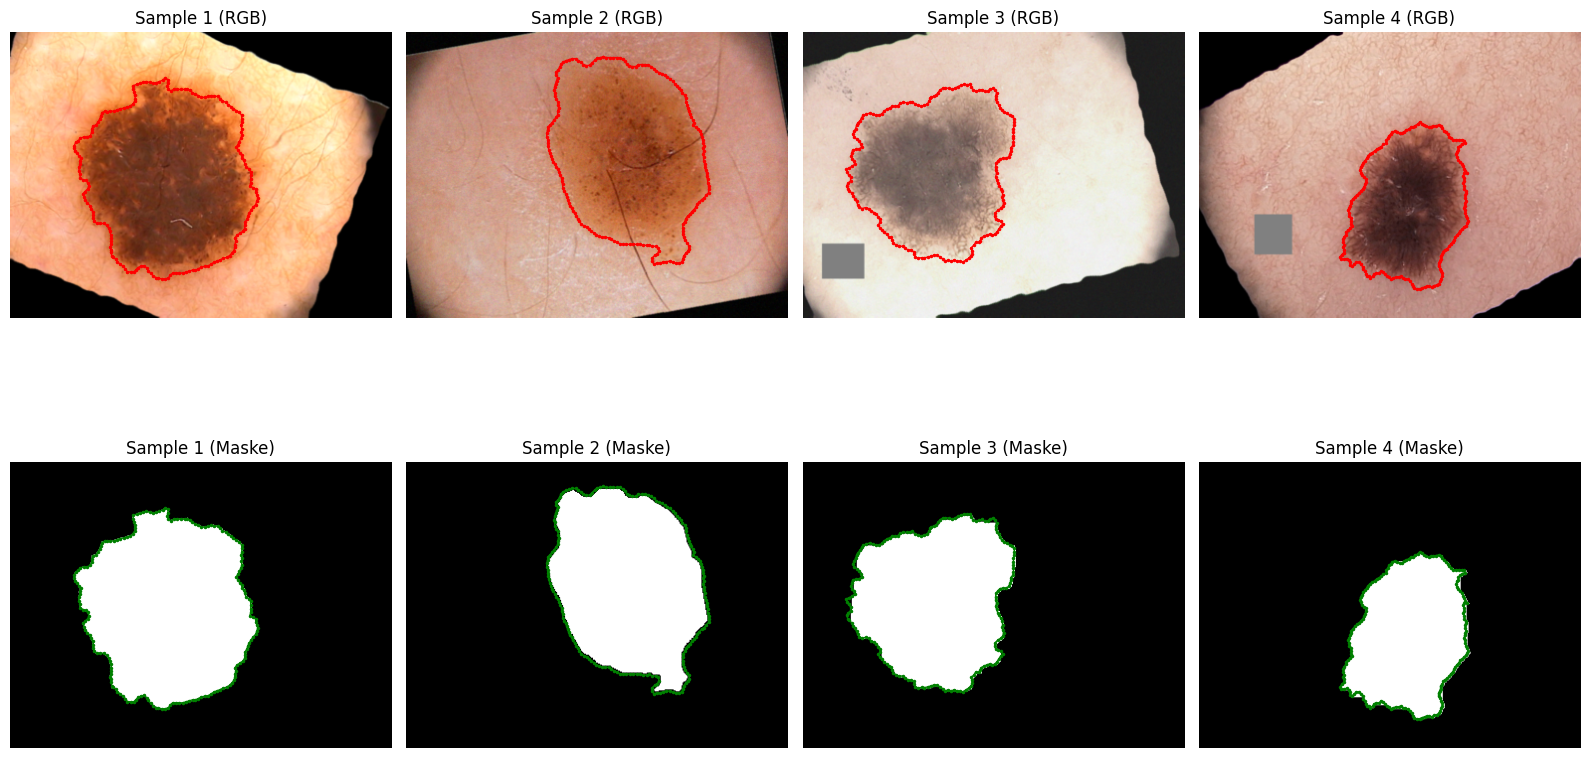


=== ISIC Dataset Test ===
Bild-Batch Form: torch.Size([8, 3, 288, 384])
Punkt-Batch Form: torch.Size([8, 200, 2])
Masken-Batch Form: torch.Size([8, 1, 288, 384])


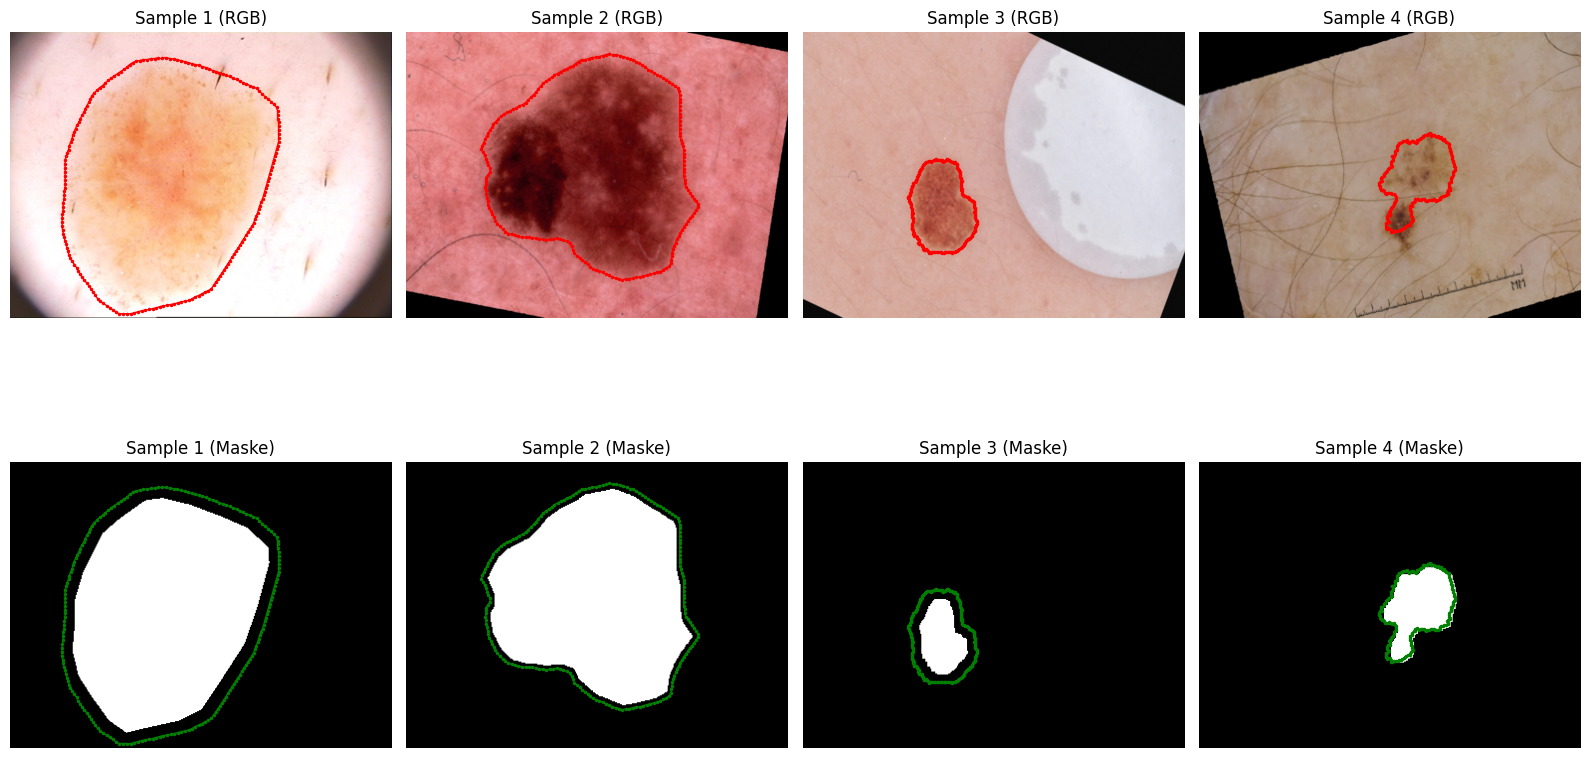

In [28]:
# ========================================================
# 1. PH2 DATALOADER TEST
# ========================================================
for batch_images, batch_points, batch_masks in ph2_dataloader:
    print("=== PH2 Dataset Test ===")
    print("Bild-Batch Form:", batch_images.shape)
    print("Punkt-Batch Form:", batch_points.shape)
    print("Masken-Batch Form:", batch_masks.shape)

    # KORREKTUR: Aufruf über die Dataset-Klasse
    PH2ContourDataset.verify_dataset(batch_images, batch_points, batch_masks)
    break # Bricht nach dem ersten Batch ab


# ========================================================
# 2. ISIC DATALOADER TEST
# ========================================================
# KORREKTUR: "isic_dataloader" statt "isic_dataset" nutzen
for batch_images, batch_points, batch_masks in isic_dataloader:
    print("\n=== ISIC Dataset Test ===")
    print("Bild-Batch Form:", batch_images.shape)
    print("Punkt-Batch Form:", batch_points.shape)
    print("Masken-Batch Form:", batch_masks.shape)

    # KORREKTUR: Aufruf über die korrekte ISIC-Dataset-Klasse
    ISIC2017ContourDataset.verify_dataset(batch_images, batch_points, batch_masks)
    break # Bricht nach dem ersten Batch ab

## **Diffusion Model**

# Test

In [25]:
import torch

# 1. Dummy-Daten erzeugen (als kämen sie aus deinem DataLoader)
batch_size = 4
dummy_bilder = torch.randn(batch_size, 4, 576, 768)
dummy_punkte = torch.rand(batch_size, 200, 2) * 2 - 1 # 4x 200 Punkte im Bereich [-1, 1]
dummy_zeit = torch.randint(0, 1000, (batch_size,))  # 4 zufällige Zeitschritte

# 2. Modelle initialisieren (UNSERE NEUE ARCHITEKTUR)
unet = FeatureUNET(in_channels=4, out_features=64)
diff_model = ContourDiffusionModel(n_punkte=200, hidden_dim=128) # context_dim ist weg!

# 3. Den Pipeline-Durchlauf testen!
with torch.no_grad():
    # Phase 1: U-Net (Die 3 Messfühler)
    wetterkarten_liste = unet(dummy_bilder)

    print("--- OUTPUT U-NET ---")
    print(f"Anzahl der extrahierten Karten: {len(wetterkarten_liste)}")

    # Phase 2: Diffusions-Modell
    predicted_noise = diff_model(dummy_punkte, dummy_zeit, wetterkarten_liste)

    print("\n--- OUTPUT DIFFUSION ---")
    print(f"Shape Predicted Noise: {predicted_noise.shape}") # Erwartet: (4, 200, 2)

print("\nBOOM! Die neue Coarse-to-Fine Architektur steht und ist mathematisch zu 100 % kompatibel!")

--- OUTPUT U-NET ---
Anzahl der extrahierten Karten: 1

--- OUTPUT DIFFUSION ---
Shape Predicted Noise: torch.Size([4, 200, 2])

BOOM! Die neue Coarse-to-Fine Architektur steht und ist mathematisch zu 100 % kompatibel!


In [29]:
import torch

# Standard DDPM Parameter
T = 1000 # 1000 Diffusions-Schritte
# Beta ist die Menge an Rauschen, die pro Schritt addiert wird.
# Es fängt winzig an (0.0001) und wird zum Schluss größer (0.02)
betas = torch.linspace(0.0001, 0.02, T)

# Alphas definieren, wie viel vom Original-Bild noch übrig ist
alphas = 1.0 - betas
# alphas_cumprod ist die kumulierte Summe. (Gibt an, wie viel Original bei Schritt t noch da ist)
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Helper-Funktion, um den richtigen Alpha-Wert für den Zeitschritt t der Batch auszuwählen
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

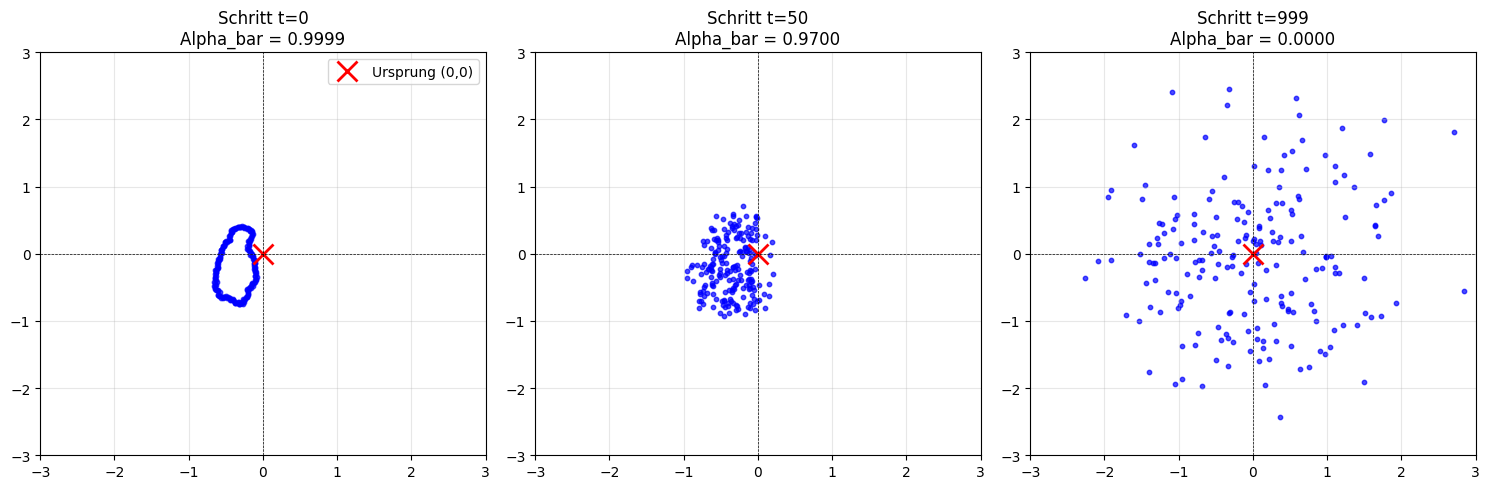

In [30]:
import matplotlib.pyplot as plt
import torch

# 1. Wir holen uns EIN Set an Punkten aus deinem Dataloader
batch_images, batch_points, batch_masks = next(iter(ph2_dataloader))
x_0 = batch_points[0]

# 2. Wir generieren das pure Zufallsrauschen (Gaussian Noise)
# Das ist exakt das, was dein 'noise = torch.randn_like(batch_points)' macht
noise = torch.randn_like(x_0)

# 3. Wir schauen uns drei Zeitpunkte an
zeitpunkte = [0, 50, 999]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, t_val in enumerate(zeitpunkte):
    # Wir holen uns den Skalierungswert für genau diesen Zeitpunkt t
    a_bar = alphas_cumprod[t_val].item()

    # DIE MAGISCHE FORMEL (Vorwärts-Diffusion)
    # x_t = (Echter Punkt * restliche Sichtbarkeit) + (Rauschen * aktuelle Rausch-Stärke)
    x_t = (x_0 * (a_bar ** 0.5)) + (noise * ((1 - a_bar) ** 0.5))

    # --- PLOTTING ---
    # Wir wandeln die Tensoren in Numpy-Arrays um
    pts = x_t.cpu().numpy()

    ax = axes[i]
    # Die Punkte zeichnen (blau)
    ax.scatter(pts[:, 0], pts[:, 1], c='blue', s=10, alpha=0.7)

    # Den Ursprung (0, 0) mit einem roten Kreuz markieren
    ax.plot(0, 0, 'rx', markersize=15, markeredgewidth=2, label="Ursprung (0,0)")

    # Die Achsen fest auf [-3, 3] setzen, damit wir den Shrink-Effekt sehen!
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"Schritt t={t_val}\nAlpha_bar = {a_bar:.4f}")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [31]:
def shoelace_area(points: torch.Tensor) -> torch.Tensor:
    """
    Fläche eines geschlossenen Polygons via Shoelace-Formel.
    points: [B, N, 2] – normalisierte Koordinaten in [-1, 1]
    returns: [B] – vorzeichenlose Fläche
    """
    x = points[..., 0]           # [B, N]
    y = points[..., 1]           # [B, N]
    x_next = torch.roll(x, -1, dims=1)
    y_next = torch.roll(y, -1, dims=1)
    area = 0.5 * torch.abs((x * y_next - x_next * y).sum(dim=1))
    return area                  # [B]

def contour_curvature(points):
    """Zweite Ableitung entlang der Kontur ≈ lokale Krümmung. [B, N, 2]"""
    p_prev = torch.roll(points,  1, dims=1)
    p_next = torch.roll(points, -1, dims=1)
    return p_next - 2 * points + p_prev  # [B, N, 2]



In [ ]:
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import copy
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
#  KONFIGURATION – hier alles einstellen
# ============================================================

RESUME_TRAINING = False         # True  → Checkpoint laden & weitertrainieren
                                # False → Frisch von vorne beginnen

# Phasenlängen
PHASE1_EPOCHS = 100             # ISIC Vortraining
PHASE2_EPOCHS = 300             # PH2 Fine-Tuning
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS  # 400

# Lernraten
LR_PHASE1 = 1e-4                # Vortraining: standard
LR_PHASE2 = 1e-5                # Fine-Tuning: 10× kleiner → kein Catastrophic Forgetting

# Speicherpfade – getrennte Checkpoints pro Phase
SAVE_PATH_PHASE1 = "/content/drive/MyDrive/best_model_phase1_isic.pth"
SAVE_PATH_PHASE2 = "/content/drive/MyDrive/best_model_phase2_ph2.pth"

tau = 0.98                      # EMA-Zerfallsrate

# ============================================================
#  DATALOADERS  (hier deine eigenen einsetzen)
# ============================================================

# dataloader_phase1 = DataLoader(ISIC2017ContourDataset(...),  batch_size=16, shuffle=True, num_workers=2)
# dataloader_phase2 = DataLoader(PH2ContourDataset(...),       batch_size=8,  shuffle=True, num_workers=2)

# ============================================================
#  MODELLE & OPTIMIZER
# ============================================================

unet       = FeatureUNET(in_channels=4, out_features=64).to(device)
diff_model = ContourDiffusionModel(n_punkte=200, hidden_dim=128).to(device)

ema_unet = copy.deepcopy(unet)
ema_diff = copy.deepcopy(diff_model)
for p in ema_unet.parameters(): p.requires_grad_(False)
for p in ema_diff.parameters(): p.requires_grad_(False)

optimizer = optim.AdamW(
    list(unet.parameters()) + list(diff_model.parameters()),
    lr=LR_PHASE1,
    weight_decay=1e-4
)

# ============================================================
#  CHECKPOINT LADEN ODER NEU STARTEN
# ============================================================

start_epoch    = 0
best_loss_p1   = float('inf')
best_loss_p2   = float('inf')
current_phase  = 1              # Wird unten ggf. überschrieben

if RESUME_TRAINING:
    # Wir schauen zuerst ob ein Phase-2-Checkpoint existiert → dann sind wir weiter
    if os.path.exists(SAVE_PATH_PHASE2):
        load_path = SAVE_PATH_PHASE2
    elif os.path.exists(SAVE_PATH_PHASE1):
        load_path = SAVE_PATH_PHASE1
    else:
        load_path = None

    if load_path:
        print(f"📂 Lade Checkpoint: {load_path}")
        checkpoint = torch.load(load_path, map_location=device)

        unet.load_state_dict(checkpoint['unet_state_dict'])
        diff_model.load_state_dict(checkpoint['diff_model_state_dict'])
        ema_unet.load_state_dict(checkpoint['unet_state_dict'])
        ema_diff.load_state_dict(checkpoint['diff_model_state_dict'])

        if 'optimizer_state_dict' in checkpoint:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            print("   ✅ Optimizer-State wiederhergestellt")

        start_epoch   = checkpoint.get('epoch', 0) + 1
        best_loss_p1  = checkpoint.get('best_loss_p1', float('inf'))
        best_loss_p2  = checkpoint.get('best_loss_p2', float('inf'))
        current_phase = 2 if start_epoch >= PHASE1_EPOCHS else 1

        # LR auf den richtigen Phasenwert setzen
        lr_restored = LR_PHASE2 if current_phase == 2 else LR_PHASE1
        for g in optimizer.param_groups:
            g['lr'] = lr_restored

        print(f"   ✅ Weiter ab Epoche {start_epoch} | Phase {current_phase} | LR={lr_restored:.0e}")
    else:
        print(f"⚠️  RESUME_TRAINING=True, aber kein Checkpoint gefunden → starte neu.")
else:
    print("🆕 Frisches Training – Phase 1 (ISIC), starte bei Epoche 0.")

# ============================================================
#  TRAINING
# ============================================================

unet.train()
diff_model.train()

scaler = torch.amp.GradScaler('cuda')
training_history = {'epoch': [], 'loss_total': [], 'phase': []}

print(f"\nTraining auf {device}")
print(f"Phase 1: Epochen 1–{PHASE1_EPOCHS}        | ISIC  | LR={LR_PHASE1:.0e}")
print(f"Phase 2: Epochen {PHASE1_EPOCHS+1}–{TOTAL_EPOCHS} | PH2   | LR={LR_PHASE2:.0e}\n")

for epoch in range(start_epoch, TOTAL_EPOCHS):

    # ----------------------------------------------------------
    #  PHASENWECHSEL LOGIK
    # ----------------------------------------------------------
    if epoch < PHASE1_EPOCHS:
        dataloader    = ph2_dataloader
        current_phase = 1
        save_path     = SAVE_PATH_PHASE1
        best_loss_ref = best_loss_p1
    else:
        dataloader    = isic_dataloader
        current_phase = 2
        save_path     = SAVE_PATH_PHASE2
        best_loss_ref = best_loss_p2

    # LR genau einmal beim Übergang von Phase 1 → Phase 2 ändern
    if epoch == PHASE1_EPOCHS:
        for g in optimizer.param_groups:
            g['lr'] = LR_PHASE2
        print(f"\n{'='*60}")
        print(f"🔀 PHASENWECHSEL: Phase 2 gestartet | LR: {LR_PHASE1:.0e} → {LR_PHASE2:.0e}")
        print(f"   Dataloader wechselt von ISIC auf PH2")
        print(f"{'='*60}\n")

    # ----------------------------------------------------------
    #  EINE EPOCHE TRAINIEREN
    # ----------------------------------------------------------
    epoch_loss_total = 0.0
    progress_bar = tqdm(
        dataloader,
        desc=f"[P{current_phase}] Epoche {epoch+1}/{TOTAL_EPOCHS}"
    )

    for batch_images, batch_points, batch_masks in progress_bar:
        batch_images = batch_images.to(device)
        batch_masks  = batch_masks.to(device)
        batch_points = batch_points.to(device)

        img_with_mask = torch.cat([batch_images, batch_masks], dim=1)
        batch_size    = batch_images.shape[0]

        optimizer.zero_grad()
        t = torch.randint(0, T, (batch_size,), device=device).long()

        with torch.amp.autocast('cuda'):
            sqrt_alphas_cumprod_t           = extract(torch.sqrt(alphas_cumprod),        t, batch_points.shape)
            sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alphas_cumprod),  t, batch_points.shape)
            noise        = torch.randn_like(batch_points)
            noisy_points = sqrt_alphas_cumprod_t * batch_points + sqrt_one_minus_alphas_cumprod_t * noise

            wetterkarten_liste = unet(img_with_mask)
            cfg_mask = (torch.rand(batch_size, device=device) < 0.15)
            wetterkarten_liste = [
                k * cfg_mask.view(-1, *([1] * (k.dim() - 1))).logical_not().float()
                for k in wetterkarten_liste
            ]

            predicted_x0 = diff_model(noisy_points, t, wetterkarten_liste)
            predicted_x0 = torch.clamp(predicted_x0, -1.2, 1.2)

            x0_weight  = extract(alphas_cumprod, t, batch_points.shape).mean()
            loss_x0    = x0_weight * F.mse_loss(predicted_x0, batch_points)

            pred_area  = shoelace_area(predicted_x0)
            gt_area    = shoelace_area(batch_points)
            loss_area  = F.l1_loss(pred_area, gt_area)

            loss_curvature = F.mse_loss(
                contour_curvature(predicted_x0),
                contour_curvature(batch_points)
            )

            loss_total = loss_x0 + 0.05 * loss_area + 0.1 * loss_curvature

        scaler.scale(loss_total).backward()
        scaler.step(optimizer)
        scaler.update()

        # EMA updaten
        for ema_p, p in zip(ema_unet.parameters(), unet.parameters()):
            ema_p.data = tau * ema_p.data + (1 - tau) * p.data
        for ema_p, p in zip(ema_diff.parameters(), diff_model.parameters()):
            ema_p.data = tau * ema_p.data + (1 - tau) * p.data

        epoch_loss_total += loss_total.item()
        progress_bar.set_postfix({
            "phase": current_phase,
            "total": f"{loss_total.item():.4f}",
            "x0":    f"{loss_x0.item():.4f}",
            "area":  f"{loss_area.item():.4f}",
            "curv":  f"{loss_curvature.item():.4f}",
        })

    # ----------------------------------------------------------
    #  EPOCH ABSCHLUSS & SPEICHERN
    # ----------------------------------------------------------
    avg_loss_total = epoch_loss_total / len(dataloader)

    training_history['epoch'].append(epoch + 1)
    training_history['loss_total'].append(avg_loss_total)
    training_history['phase'].append(current_phase)

    print(f"[P{current_phase}] Epoche {epoch+1} | Total: {avg_loss_total:.4f}")

    # Besten Loss der aktuellen Phase vergleichen und ggf. speichern
    if avg_loss_total < best_loss_ref:
        if current_phase == 1:
            best_loss_p1 = avg_loss_total
        else:
            best_loss_p2 = avg_loss_total

        torch.save({
            'unet_state_dict':       ema_unet.state_dict(),
            'diff_model_state_dict': ema_diff.state_dict(),
            'optimizer_state_dict':  optimizer.state_dict(),
            'epoch':                 epoch,
            'phase':                 current_phase,
            'best_loss_p1':          best_loss_p1,
            'best_loss_p2':          best_loss_p2,
        }, save_path)

        print(f"   ✅ Neuer Rekord Phase {current_phase}! "
              f"Epoche {epoch+1} gesichert → {save_path} "
              f"(Loss: {avg_loss_total:.4f})")

🆕 Frisches Training – Phase 1 (ISIC), starte bei Epoche 0.

Training auf cuda
Phase 1: Epochen 1–100        | ISIC  | LR=1e-04
Phase 2: Epochen 101–400 | PH2   | LR=1e-05



[P1] Epoche 1/400: 100%|██████████| 25/25 [00:44<00:00,  1.76s/it, phase=1, total=0.0651, x0=0.0315, area=0.6079, curv=0.0313]


[P1] Epoche 1 | Total: 0.1110
   ✅ Neuer Rekord Phase 1! Epoche 1 gesichert → /content/drive/MyDrive/best_model_phase1_isic.pth (Loss: 0.1110)


[P1] Epoche 2/400: 100%|██████████| 25/25 [00:47<00:00,  1.89s/it, phase=1, total=0.0637, x0=0.0357, area=0.5230, curv=0.0187]


[P1] Epoche 2 | Total: 0.0669
   ✅ Neuer Rekord Phase 1! Epoche 2 gesichert → /content/drive/MyDrive/best_model_phase1_isic.pth (Loss: 0.0669)


...

[P1] Epoche 11/400: 100%|██████████| 25/25 [00:42<00:00,  1.72s/it, phase=1, total=0.0563, x0=0.0186, area=0.7032, curv=0.0252]


[P1] Epoche 11 | Total: 0.0431
   ✅ Neuer Rekord Phase 1! Epoche 11 gesichert → /content/drive/MyDrive/best_model_phase1_isic.pth (Loss: 0.0431)


[P1] Epoche 12/400: 100%|██████████| 25/25 [00:49<00:00,  1.97s/it, phase=1, total=0.0322, x0=0.0135, area=0.3310, curv=0.0214]


[P1] Epoche 12 | Total: 0.0424
   ✅ Neuer Rekord Phase 1! Epoche 12 gesichert → /content/drive/MyDrive/best_model_phase1_isic.pth (Loss: 0.0424)


[P1] Epoche 13/400:  60%|██████    | 15/25 [00:32<00:18,  1.88s/it, phase=1, total=0.0459, x0=0.0230, area=0.4367, curv=0.0113]

In [ ]:
# WICHTIG: Die Keys müssen exakt mit dem Dictionary aus der Trainingsschleife übereinstimmen
plt.figure(figsize=(10, 5))

# Die drei Loss-Komponenten plotten
plt.plot(training_history['epoch'], training_history['loss_total'], marker='', linestyle='-', color='black', linewidth=2, label='Total Loss')
#plt.plot(training_history['epoch'], training_history['loss_noise'], marker='', linestyle='--', color='blue', alpha=0.7, label='Noise Loss (MSE)')
#plt.plot(training_history['epoch'], training_history['loss_struktur'], marker='', linestyle='-.', color='red', alpha=0.7, label='Struktur Loss (PointNet)')

plt.title("Trainingsverlauf: Loss-Komponenten über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Durchschnittlicher Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Sichert den Plot als Datei (verhindert Datenverlust bei VS Code Absturz)
plt.savefig("trainingsverlauf_loss.png", dpi=300)

# Zeigt den Plot zusätzlich an
plt.show()

In [ ]:
import numpy as np
np.min(training_history['loss_total'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

T = 1000
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

unet.eval()
diff_model.eval()

# 1. Funktion anpassen: Sie braucht nun auch mask_tensor
def sample_contour(unet_model, diffusion_model, image_tensor, mask_tensor, T_steps=1000, ddim_steps=50, guidance_scale=5.0):
    with torch.no_grad():
        # Bild + Maske kombinieren für U-Net
        img_with_mask = torch.cat([image_tensor.to(device), mask_tensor.to(device)], dim=1)
        wetterkarte = unet_model(img_with_mask)

        # Start: pures Rauschen
        x = torch.randn(1, 200, 2).to(device)

        # DDIM: nur 50 Zeitschritte statt 1000
        step_size = T_steps // ddim_steps
        timesteps = list(reversed(range(0, T_steps, step_size)))
        # → [980, 960, 940, ..., 20, 0]

        for idx, t in enumerate(tqdm(timesteps, desc=f"DDIM ({ddim_steps} Schritte)", total=len(timesteps))):
            t_tensor = torch.tensor([t], device=device).long()

            # x0 direkt vorhersagen mit CFG
            with torch.amp.autocast('cuda'):
                x0_cond   = diffusion_model(x, t_tensor, wetterkarte)
                x0_uncond = diffusion_model(x, t_tensor, [torch.zeros_like(k) for k in wetterkarte])
                predicted_x0 = x0_uncond + guidance_scale * (x0_cond - x0_uncond)
                predicted_x0 = torch.clamp(predicted_x0, -1.0, 1.0)

            alpha_t_bar = alphas_cumprod[t]

            # Vorheriger Zeitschritt – beim letzten Schritt: alpha=1.0 → x = predicted_x0
            t_prev = timesteps[idx + 1] if idx + 1 < len(timesteps) else -1
            alpha_t_bar_prev = alphas_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=device)

            # DDIM Update: deterministisch, kein Rauschen
            direction = (x - torch.sqrt(alpha_t_bar) * predicted_x0) / torch.sqrt(1.0 - alpha_t_bar)
            x = torch.sqrt(alpha_t_bar_prev) * predicted_x0 + torch.sqrt(1.0 - alpha_t_bar_prev) * direction

    return x

# --- VISUALISIERUNG ---
# Wir ändern das Grid auf 3 Zeilen und 3 Spalten
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for i in range(3):
    test_images, test_points, test_masks = next(iter(dataloader))

    single_image = test_images[0].unsqueeze(0)
    single_mask = test_masks[0].unsqueeze(0)
    echte_punkte = test_points[0].numpy()

    generierte_punkte = sample_contour(unet, diff_model, single_image, single_mask, T_steps=T).cpu().squeeze().numpy()

    # Bild vorbereiten
    img_vis = single_image.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_vis = (img_vis * 0.5) + 0.5
    img_vis = np.clip(img_vis, 0, 1)
    H, W = img_vis.shape[:2]

    # Maske für Matplotlib vorbereiten (1-Kanal Tensor zu 2D Array)
    mask_vis = single_mask.squeeze().cpu().numpy()

    gen_x = (generierte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
    gen_y = (generierte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)
    echt_x = (echte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
    echt_y = (echte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

    # --- Spalte 1: Ground Truth ---
    axes[i, 0].imshow(img_vis)
    axes[i, 0].plot(echt_x, echt_y, 'g.-', markersize=6, linewidth=1.5, label="Ground Truth")
    axes[i, 0].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5)
    axes[i, 0].set_title(f"Sample {i+1} - Ground Truth")
    axes[i, 0].legend()
    axes[i, 0].axis("off")

    # --- Spalte 2: U-Net Input (Maske) ---
    axes[i, 1].imshow(mask_vis, cmap='gray')
    # Den echten Rand als grüne Linie drüberlegen, um den Versatz durch Dilation/Erosion zu sehen
    axes[i, 1].plot(echt_x, echt_y, 'g-', alpha=0.8, linewidth=1.5, label="Echter Rand")
    axes[i, 1].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5)
    axes[i, 1].set_title(f"Sample {i+1} - U-Net Input (Maske)")
    axes[i, 1].legend()
    axes[i, 1].axis("off")

    # --- Spalte 3: Modellvorhersage ---
    axes[i, 2].imshow(img_vis)
    axes[i, 2].plot(echt_x, echt_y, 'g-', alpha=0.3, linewidth=2, label="Ground Truth")
    axes[i, 2].scatter(gen_x, gen_y, c='red', s=35, label="KI Generiert")
    axes[i, 2].set_title(f"Sample {i+1} - Vorhersage")
    axes[i, 2].legend()
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("generierte_konturen_grid_mit_maske.png", bbox_inches='tight', dpi=300)
plt.show()